In [19]:
# =============================================================================
# SOFTWARE DEFECT PREDICTION: ADABOOST VS. EXTRA TREES
# =============================================================================
# 1. EDA Visualizations
# 2. Manual Oversampling for Balanced Learning
# 3. Model Training: AdaBoost & Extra Trees
# 4. Professional Performance Rank Table
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import warnings

# --- Setup & Style ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [20]:
# -----------------------------------------------------------------------------
# STEP 1: DATA LOADING
# -----------------------------------------------------------------------------
try:
    df = pd.read_csv('software_defect_prediction_dataset (1).csv')
    print("✓ Dataset loaded successfully.")
except Exception as e:
    print(f"Error: {e}. Please ensure the CSV file is uploaded.")

✓ Dataset loaded successfully.


In [21]:
df.head()

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,910,12,7,79,0.59,539,19,4,23,7,...,70,1,54,27,0.06,3,20,31,21,1
1,3822,9,197,72,0.30,584,8,8,126,153,...,180,5,73,23,0.39,9,154,38,29,1
2,3142,20,99,92,0.11,593,0,6,272,177,...,152,5,9,31,0.08,7,425,22,6,1
3,516,39,52,79,0.18,81,12,14,16,0,...,159,9,23,12,0.44,2,339,24,12,1
4,4476,27,162,75,0.21,918,14,1,164,109,...,169,2,84,9,0.41,3,111,19,2,1


In [22]:
df.tail()

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
59995,3521,4,45,93,0.49,742,0,4,237,0,...,186,9,43,18,0.41,12,215,29,1,1
59996,4286,26,194,79,0.17,878,16,12,179,74,...,86,4,59,45,0.62,3,4,31,4,1
59997,919,46,119,42,0.03,649,1,5,194,42,...,9,1,16,18,0.93,13,207,36,5,1
59998,3127,10,120,22,0.25,971,5,11,268,141,...,38,1,34,48,0.22,0,117,6,16,1
59999,3863,27,119,18,0.58,690,16,6,196,17,...,137,9,57,39,0.83,0,102,11,11,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   lines_of_code               60000 non-null  int64  
 1   cyclomatic_complexity       60000 non-null  int64  
 2   num_functions               60000 non-null  int64  
 3   num_classes                 60000 non-null  int64  
 4   comment_density             60000 non-null  float64
 5   code_churn                  60000 non-null  int64  
 6   developer_experience_years  60000 non-null  int64  
 7   num_developers              60000 non-null  int64  
 8   commit_frequency            60000 non-null  int64  
 9   bug_fix_commits             60000 non-null  int64  
 10  past_defects                60000 non-null  int64  
 11  test_coverage               60000 non-null  float64
 12  duplication_percentage      60000 non-null  float64
 13  avg_function_length         600

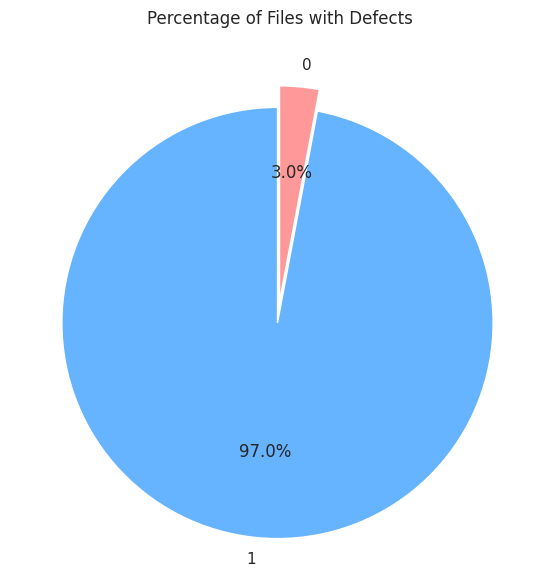

In [24]:
# 1. Pie Chart: Overall Defect Percentage
plt.figure(figsize=(7,7))
df['defect'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=(0.1, 0))
plt.title('Percentage of Files with Defects')
plt.ylabel('')
plt.show()

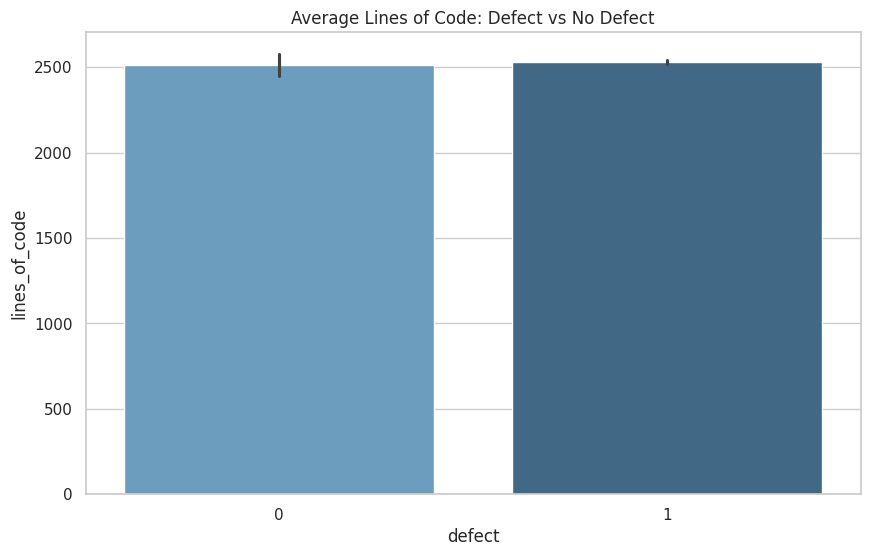

In [25]:
# 2. Bar Plot: Average Lines of Code
plt.figure()
sns.barplot(x='defect', y='lines_of_code', data=df, palette='Blues_d')
plt.title('Average Lines of Code: Defect vs No Defect')
plt.show()

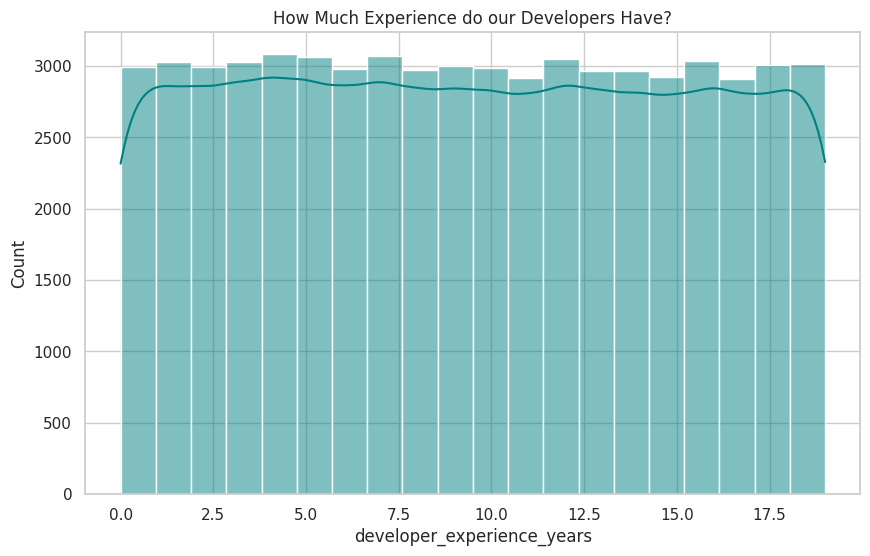

In [26]:
# 3. Histogram: Distribution of Developer Experience
plt.figure()
sns.histplot(df['developer_experience_years'], bins=20, color='teal', kde=True)
plt.title('How Much Experience do our Developers Have?')
plt.show()

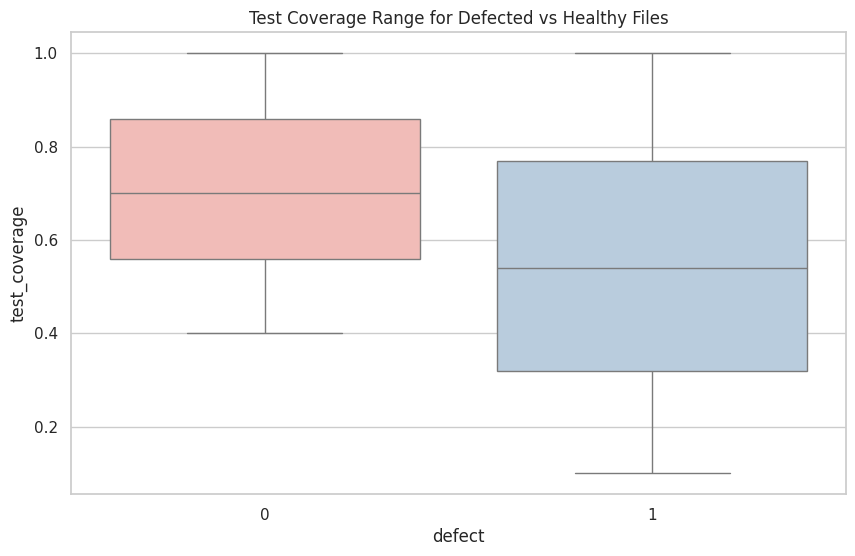

In [27]:
# 4. Box Plot: Test Coverage Impact
plt.figure()
sns.boxplot(x='defect', y='test_coverage', data=df, palette='Pastel1')
plt.title('Test Coverage Range for Defected vs Healthy Files')
plt.show()

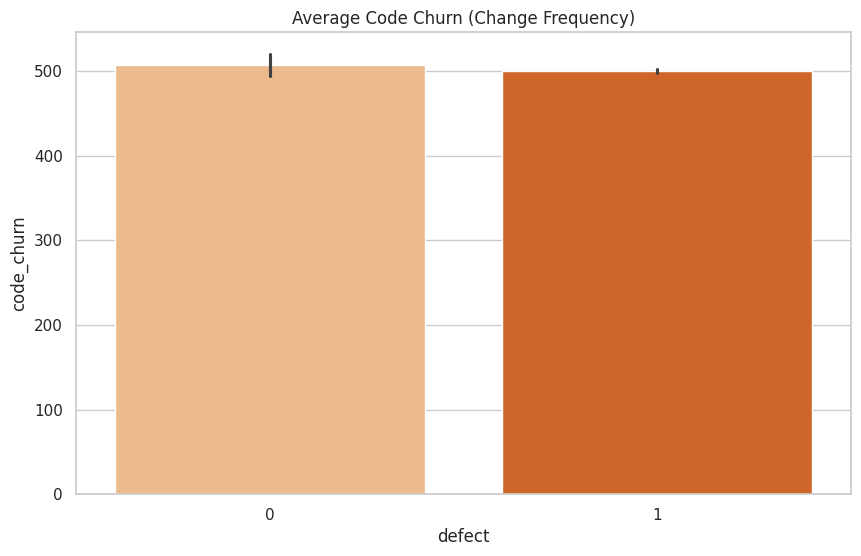

In [28]:
# 5. Bar Plot: Average Code Churn (Frequency of Changes)
plt.figure()
sns.barplot(x='defect', y='code_churn', data=df, palette='Oranges')
plt.title('Average Code Churn (Change Frequency)')
plt.show()

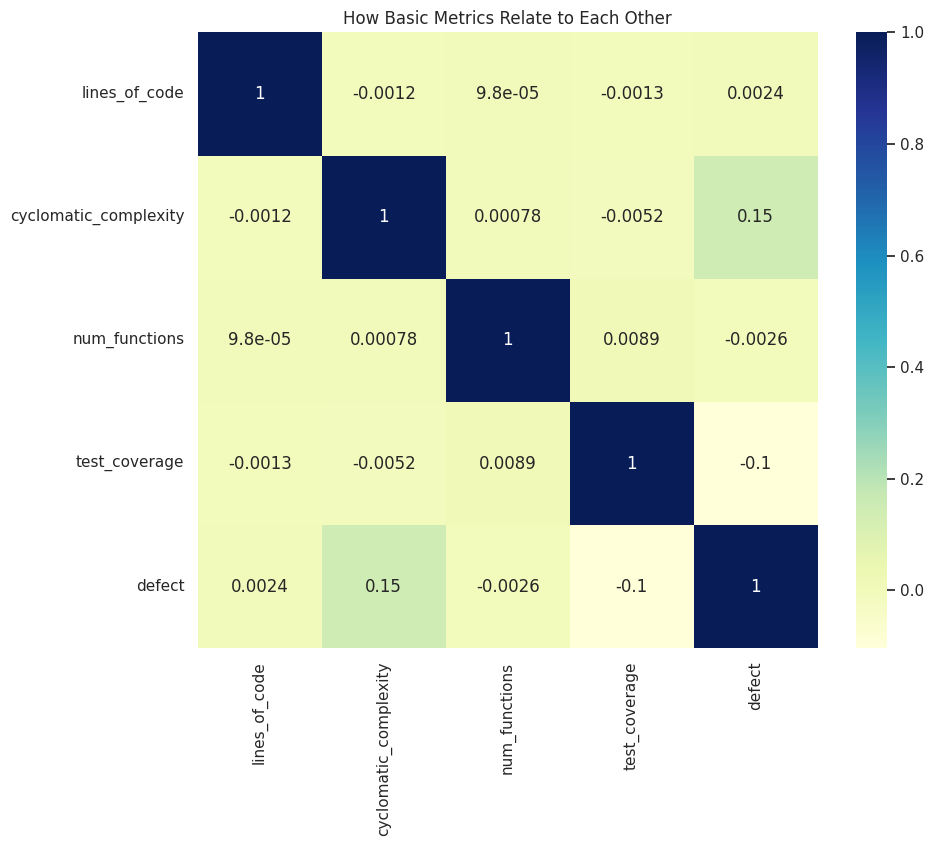

In [29]:
# 6. Correlation Heatmap (Simplified for beginners)
plt.figure(figsize=(10, 8))
core_metrics = ['lines_of_code', 'cyclomatic_complexity', 'num_functions', 'test_coverage', 'defect']
sns.heatmap(df[core_metrics].corr(), annot=True, cmap='YlGnBu')
plt.title('How Basic Metrics Relate to Each Other')
plt.show()

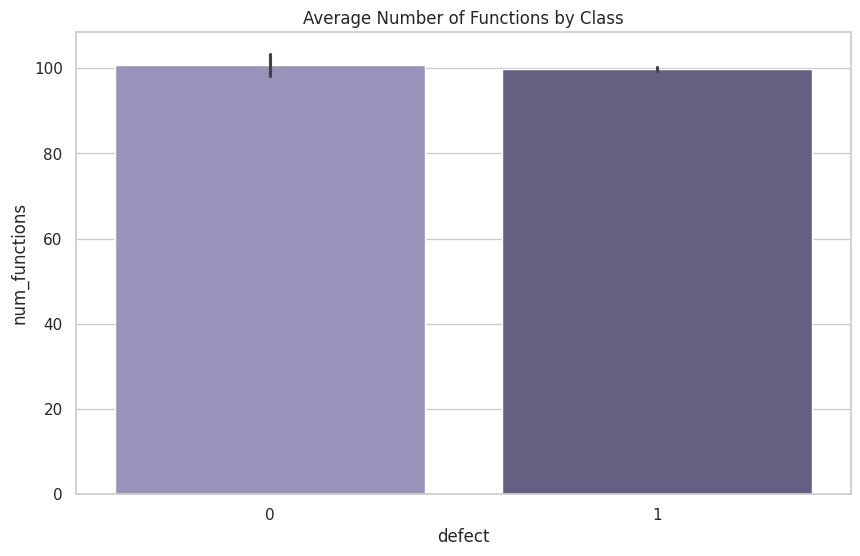

In [30]:
# 7. Bar Plot: Number of Functions per Class
plt.figure()
sns.barplot(x='defect', y='num_functions', data=df, palette='Purples_d')
plt.title('Average Number of Functions by Class')
plt.show()

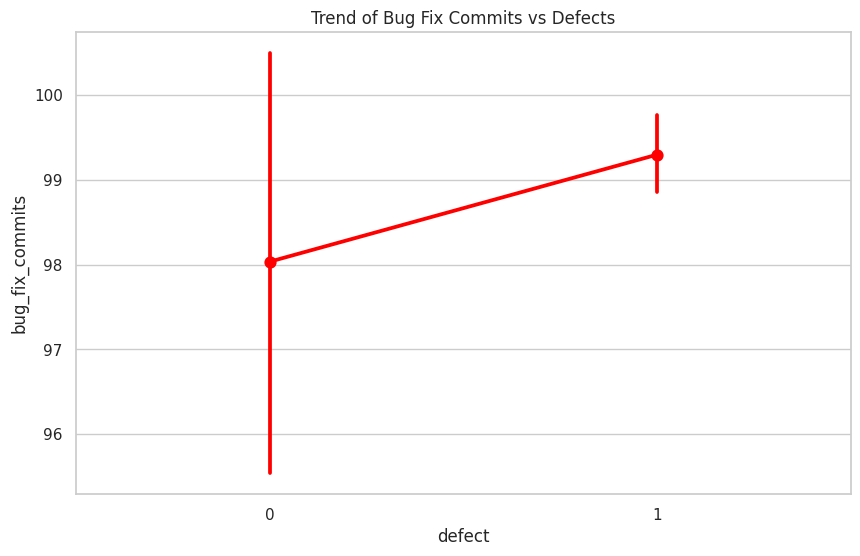

In [31]:
# 8. Point Plot: Bug Fix Commits Trend
plt.figure()
sns.pointplot(x='defect', y='bug_fix_commits', data=df, color='red')
plt.title('Trend of Bug Fix Commits vs Defects')
plt.show()

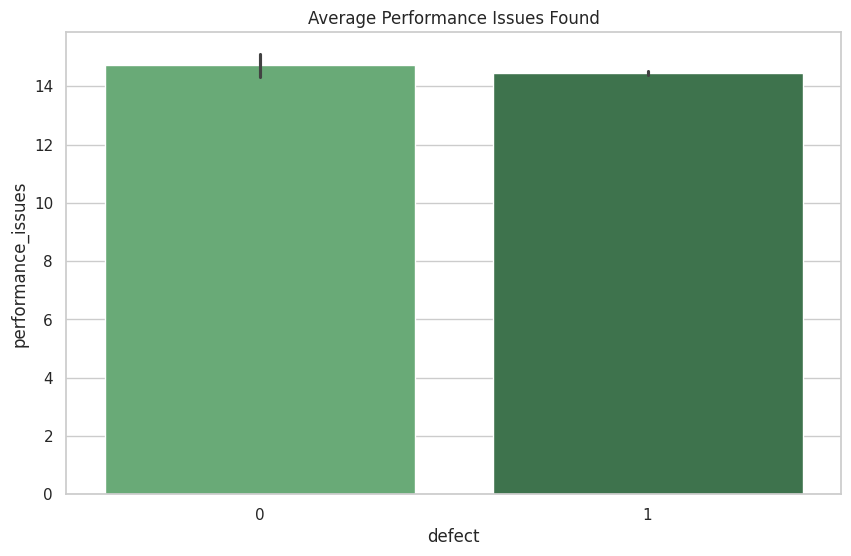

In [32]:
# 9. Bar Plot: Performance Issues vs Defect
plt.figure()
sns.barplot(x='defect', y='performance_issues', data=df, palette='Greens_d')
plt.title('Average Performance Issues Found')
plt.show()

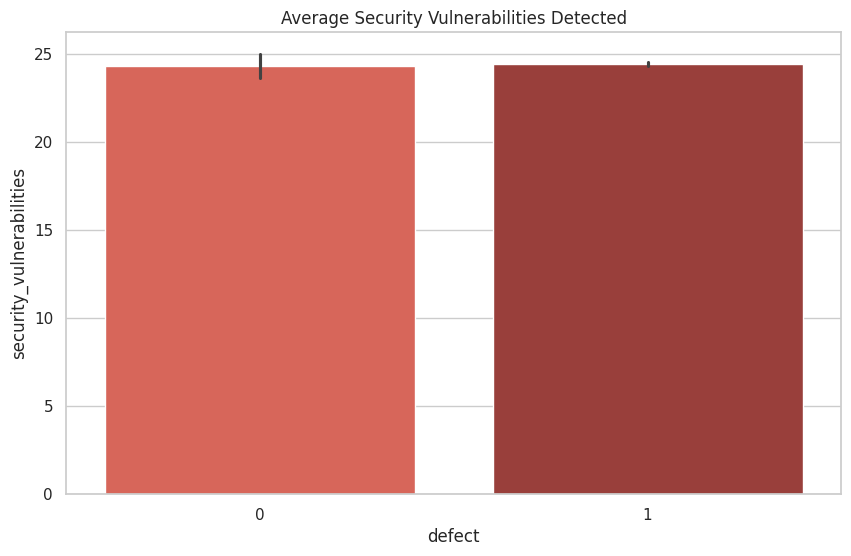

In [33]:
# 10. Bar Plot: Security Vulnerabilities vs Defect
plt.figure()
sns.barplot(x='defect', y='security_vulnerabilities', data=df, palette='Reds_d')
plt.title('Average Security Vulnerabilities Detected')
plt.show()

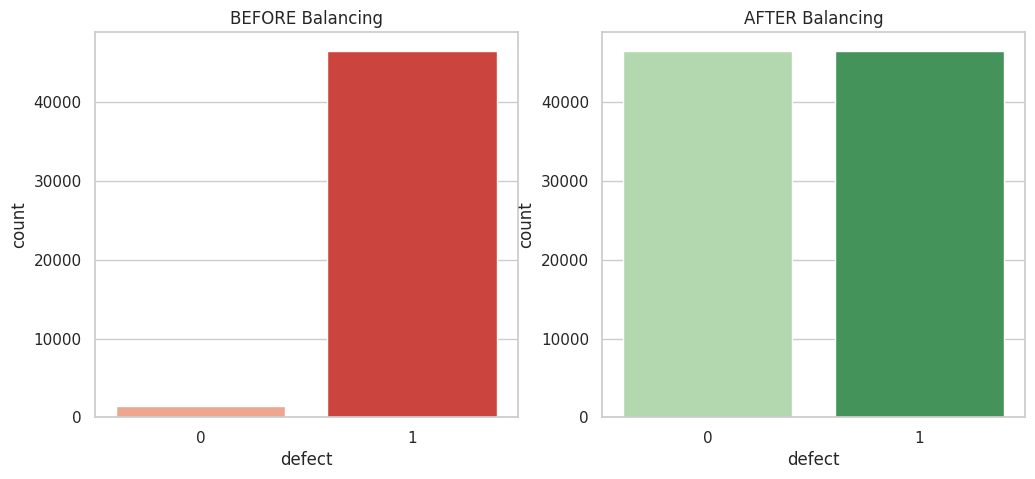

In [34]:
# -----------------------------------------------------------------------------
# STEP 3: OVERSAMPLING (HANDLING THE IMBALANCE)
# -----------------------------------------------------------------------------
X = df.drop('defect', axis=1)
y = df['defect']

# Split first to prevent data leakage
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Combine for resampling
train_combined = pd.concat([X_train_raw, y_train_raw], axis=1)
df_maj = train_combined[train_combined.defect == 1]
df_min = train_combined[train_combined.defect == 0]

# Upsample minority (No Defects) to match majority (Defects)
df_min_upsampled = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
train_balanced = pd.concat([df_maj, df_min_upsampled])

# Visualizing the Balancing result
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='defect', data=train_combined, palette='Reds')
plt.title('BEFORE Balancing')
plt.subplot(1, 2, 2)
sns.countplot(x='defect', data=train_balanced, palette='Greens')
plt.title('AFTER Balancing')
plt.show()

X_train_final = train_balanced.drop('defect', axis=1)
y_train_final = train_balanced['defect']

In [36]:
# -----------------------------------------------------------------------------
# STEP 4: MODEL TRAINING (ADABOOST & EXTRA TREES)
# -----------------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

models = {
    "AdaBoost Classifier": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Extra Trees Classifier": ExtraTreesClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train_final)
    preds = model.predict(X_test_scaled)

    results.append({
        "Algorithm": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall": round(recall_score(y_test, preds), 4),
        "F1-Score": round(f1_score(y_test, preds), 4)
    })


FINAL STUDENT RANK TABLE (BALANCED)
                   Algorithm  Accuracy  Precision  Recall  F1-Score
Rank                                                               
1        AdaBoost Classifier    1.0000     1.0000     1.0    1.0000
2     Extra Trees Classifier    0.9755     0.9754     1.0    0.9875


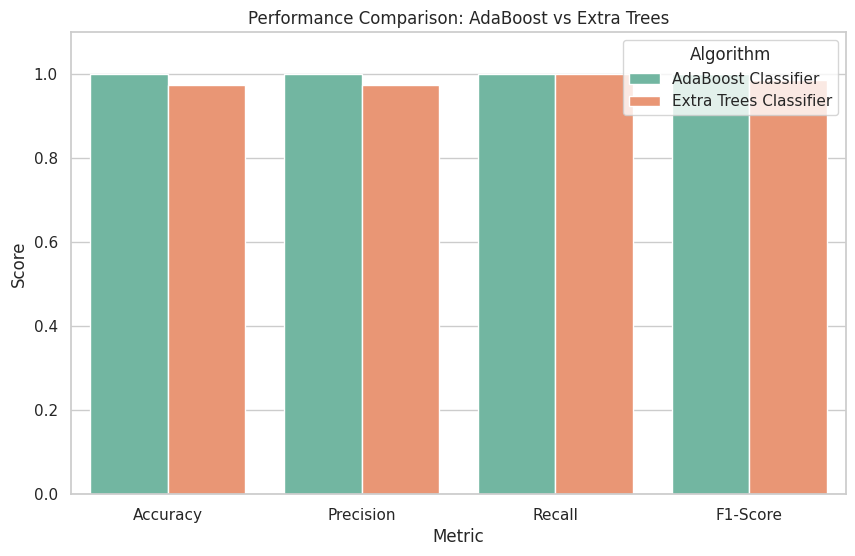

In [37]:
# -----------------------------------------------------------------------------
# STEP 5: RANK TABLE & EVALUATION
# -----------------------------------------------------------------------------
rank_table = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
rank_table.index += 1
rank_table.index.name = "Rank"

print("\n" + "="*50)
print("FINAL STUDENT RANK TABLE (BALANCED)")
print("="*50)
print(rank_table)

# Visual Metric Comparison
plt.figure()
plot_df = rank_table.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=plot_df, palette='Set2')
plt.title('Performance Comparison: AdaBoost vs Extra Trees')
plt.ylim(0, 1.1)
plt.show()